# REINFORCE: Monte-Carlo Control with Policy Approximation

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [1]:
import numpy as np
np.set_printoptions(precision=2)

In [2]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

## Define the L-Maze Grid World 

In [3]:
gym_env = gym.make('LMaze-v0', tabular = False)
env = gym_env.unwrapped

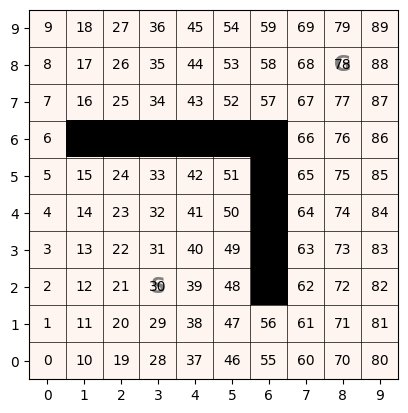

In [4]:
env.image()

## Policy Approximation: Linear Soft-Max In Action Preferences

Use Fourier-basis transformation and set up state-action features.

In [5]:
from gym_classics.algorithms.linear_approximation import transformation_fourier_basis, active_weights

trans_fb = transformation_fourier_basis(min = np.array([0,0]), max = env.dims, order=2)

def state_features(s,env):
    return trans_fb(s)

In [6]:
def state_action_features(s,a,env):
    s = state_features(s,env)
    x = np.zeros(1+len(s)*env.action_space.n)
    x[active_weights(a, len(s)-1)] = s
    return x

Define the preference function $h(s,a,\bf{\theta})=\bf{\theta}^\top \bf{x}(s,a)$

In [7]:
def h(s,a,theta,env):
    return np.dot(theta, state_action_features(s,a,env))

Soft-max transformation from scores to a probability distribution: $\pi(s,a,\theta) = \frac{e^{h(s,a,\bf{\theta})}}{\sum_b h(s,a,\bf{\theta})}$

In [8]:
def pi(s,theta,env):
    hs = np.array([h(s,a,theta,env) for a in range(env.action_space.n)])
    exp_hs = np.exp(hs)
    return exp_hs / np.sum(exp_hs)

Check with a random weight vector.

In [9]:
theta = np.random.rand(1+len(state_features(0, env))*env.action_space.n)
theta

array([0.98, 0.56, 0.43, 0.84, 0.32, 0.97, 0.16, 0.17, 0.73, 0.08, 0.84,
       0.87, 0.65, 0.82, 0.3 , 0.08, 0.34, 0.62, 0.78, 0.46, 0.98, 0.31,
       0.71, 0.47, 0.6 , 0.64, 0.27, 0.96, 0.01, 0.27, 0.9 , 0.14, 0.08,
       0.58, 0.39, 0.91, 0.43])

Calculate the preferences score for all actions for state 0.

In [10]:
[h(0,a,theta, env) for a in range(env.action_space.n)] 

[np.float64(5.151516488968822),
 np.float64(4.960938395819724),
 np.float64(5.912249372208377),
 np.float64(4.246996750941774)]

Calculate $\pi(s,a,\theta)$ for all actions in state $s=0$

In [11]:
pi(0,theta,env)

array([0.23, 0.19, 0.49, 0.09])

## REINFORCE: Monte-Carlo Control

![Pseudocode REINFORCE](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_REINFORCE.png)

We need to sample following a stochastic policy.

In [12]:
def sample_episode_policy(env, pi, theta, max_episode_length=1000):
    """
    Sample an episode using the policy defined by pi and theta.
    Returns a list of (state, action, reward) tuples.
    """
    s, _ = env.reset()
    episode_data = []
    
    for t in range(max_episode_length):
        a = np.random.choice(range(env.action_space.n), p=pi(s,theta,env))
        next_s, r, done, _, _ = env.step(a)
        episode_data.append((s, a, r, next_s))
        s = next_s
        
        if done:
            break
    
    return episode_data


In [13]:
episode_data = sample_episode_policy(env, pi, theta)
episode_data

[((3, 2), np.int64(1), 0.0, (4, 2)),
 ((4, 2), np.int64(3), 0.0, (3, 2)),
 ((3, 2), np.int64(3), 0.0, (2, 2)),
 ((2, 2), np.int64(0), 0.0, (2, 3)),
 ((2, 3), np.int64(1), 0.0, (3, 3)),
 ((3, 3), np.int64(0), 0.0, (3, 4)),
 ((3, 4), np.int64(3), 0.0, (2, 4)),
 ((2, 4), np.int64(1), 0.0, (3, 4)),
 ((3, 4), np.int64(3), 0.0, (2, 4)),
 ((2, 4), np.int64(0), 0.0, (2, 5)),
 ((2, 5), np.int64(3), 0.0, (1, 5)),
 ((1, 5), np.int64(3), 0.0, (0, 5)),
 ((0, 5), np.int64(2), 0.0, (0, 4)),
 ((0, 4), np.int64(3), 0.0, (0, 4)),
 ((0, 4), np.int64(3), 0.0, (0, 4)),
 ((0, 4), np.int64(3), 0.0, (0, 4)),
 ((0, 4), np.int64(3), 0.0, (0, 4)),
 ((0, 4), np.int64(3), 0.0, (0, 4)),
 ((0, 4), np.int64(2), 0.0, (0, 3)),
 ((0, 3), np.int64(1), 0.0, (1, 3)),
 ((1, 3), np.int64(3), 0.0, (0, 3)),
 ((0, 3), np.int64(3), 0.0, (0, 3)),
 ((0, 3), np.int64(0), 0.0, (0, 4)),
 ((0, 4), np.int64(3), 0.0, (0, 4)),
 ((0, 4), np.int64(3), 0.0, (0, 4)),
 ((0, 4), np.int64(3), 0.0, (0, 4)),
 ((0, 4), np.int64(1), 0.0, (1, 4)),
 

Implement the REINFORCE algorithm. The gradient of the policy for linear approximation is proportional to  $\nabla ln\ \pi(s,a,\bf{\theta}) =   \bf{x}(s,a) - \sum_b \pi(b|s,\bf{\theta}) \bf{x}(s,b)$

In [ ]:
from gym_classics.algorithms.schedules import LinearDecaySchedule, ConstantSchedule
from tqdm import tqdm

def REINFORCE(
    env,
    n,
    alpha,
    gamma,
    theta = None,
    max_episode_length=1000,
    verbose=False,
    history=False
    ):
    
    if theta is None:
        state, _ = env.reset()  
        theta = np.zeros(1 + len(state_features(state, env)) * env.action_space.n)
    
    if history:
        returns = []        
        ep_lens = []
        thetas = []
        thetas.append(theta.copy())
        
    for episode in tqdm(range(n), desc="Episodes", disable=verbose):
        if verbose:
            print(f"Episode {episode+1}/{n}")
        
        episode_data = sample_episode_policy(env, pi, theta, max_episode_length)
        
        for t in range(len(episode_data)):
            G = np.sum([e[2] for e in episode_data[t:]] * (gamma ** np.arange(len(episode_data[t:]))))
            if history and t == 0:
                returns.append(G)   

            s,a,r,next_s = episode_data[t]
            
            # ln policy gradient= x(s,a)- sum_b pi(b|s,theta) x(s,b)
            grad_log_pi = state_action_features(s, a, env) - sum([pi(s, theta, env)[b] * state_action_features(s, b, env) for b in range(env.action_space.n)])
            
            if verbose: 
                print (f"t: {t}, G: {G}, grad_log_pi: {grad_log_pi}")
            
            theta += alpha(episode) * (gamma**t) * G * grad_log_pi
            
        if history:
            thetas.append(theta.copy())
            ep_lens.append(len(episode_data))
            
    if history:
        return theta, {'thetas': thetas, 'returns': returns, 'ep_lens': ep_lens}
       
    return theta

In [28]:
theta, history = REINFORCE(env, n=2000, 
                           alpha=LinearDecaySchedule(0.1, 0.001, 1000),
                           gamma=0.99, 
                           max_episode_length = 500,
                           history=True)

Episodes: 100%|██████████| 2000/2000 [00:22<00:00, 90.80it/s]


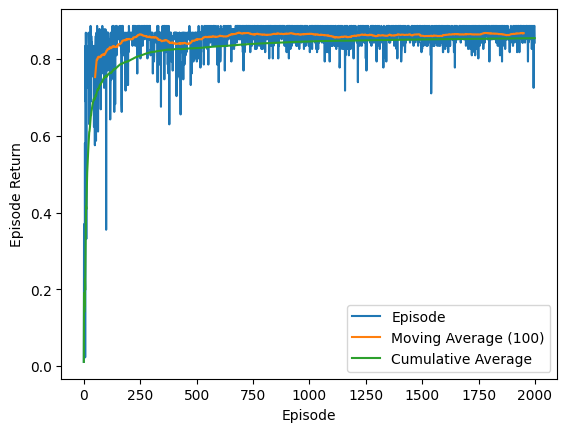

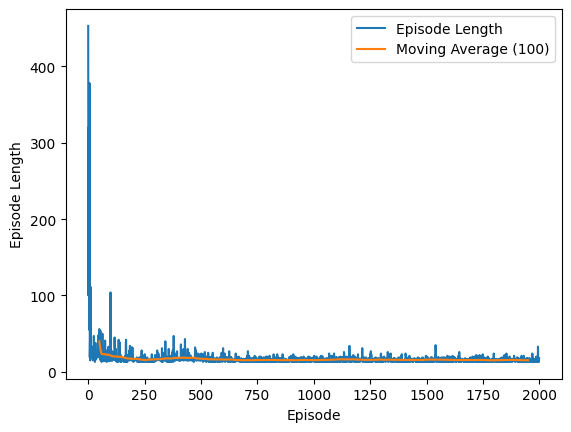

In [29]:
from gym_classics.performance import plot_returns, plot_ep_lens
plot_returns(history['returns'])
plot_ep_lens(history['ep_lens'])

Note: MC produces initially high variance.

## The Learned Policy

In [30]:
pol = [pi(env.id2state(s), theta,env) for s in env.states()]
pol

[array([1.07e-01, 8.89e-01, 6.38e-05, 3.29e-03]),
 array([1.58e-01, 8.34e-01, 2.03e-04, 7.17e-03]),
 array([0.36, 0.59, 0.  , 0.05]),
 array([0.48, 0.17, 0.08, 0.26]),
 array([0.18, 0.02, 0.4 , 0.4 ]),
 array([0.05, 0.  , 0.66, 0.29]),
 array([0.02, 0.  , 0.72, 0.26]),
 array([0.03, 0.01, 0.64, 0.32]),
 array([0.06, 0.03, 0.47, 0.44]),
 array([0.09, 0.14, 0.3 , 0.48]),
 array([4.84e-02, 9.49e-01, 8.42e-05, 2.42e-03]),
 array([3.83e-02, 9.57e-01, 3.82e-04, 4.34e-03]),
 array([0.08, 0.87, 0.01, 0.04]),
 array([0.12, 0.25, 0.39, 0.24]),
 array([0.02, 0.01, 0.81, 0.16]),
 array([6.24e-03, 6.08e-04, 8.86e-01, 1.07e-01]),
 array([0.02, 0.  , 0.75, 0.23]),
 array([0.05, 0.02, 0.53, 0.4 ]),
 array([0.1 , 0.14, 0.3 , 0.46]),
 array([5.46e-03, 9.93e-01, 1.60e-04, 9.62e-04]),
 array([0.  , 0.99, 0.  , 0.  ]),
 array([0.01, 0.92, 0.06, 0.02]),
 array([0.01, 0.09, 0.85, 0.06]),
 array([0.  , 0.  , 0.97, 0.03]),
 array([1.10e-03, 1.28e-04, 9.69e-01, 2.95e-02]),
 array([0.02, 0.  , 0.79, 0.19]),
 arr

Visualize the learned policy by showing the action with the highest probability. The probability is shown using the tile color. 
Closer to 1 means that the algorithm is more sure about the action. Smaller values means that the algorithms still would like to explore.

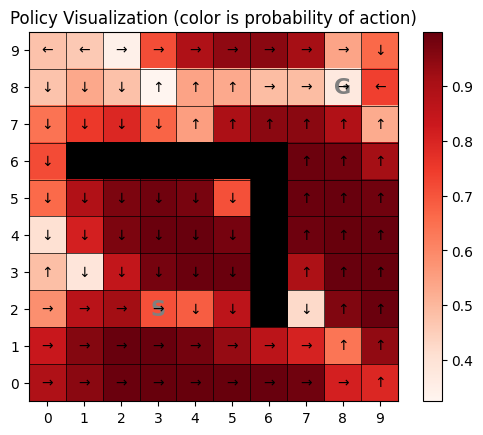

In [31]:
pol_discrete = np.argmax(pol, axis=1)
prob = np.max(pol, axis=1)
env.image(V=prob, policy=pol_discrete, title="Policy Visualization (color is probability of action)")

Visualize the found path using the highest probability action.

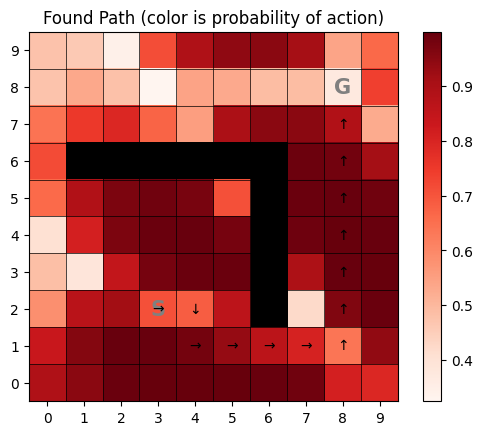

In [35]:
from gym_classics.algorithms.monte_carlo_methods import sample_episode

path = sample_episode(env, policy=pol_discrete, max_len=100)
path = [(env.state2id(s), a, r,env.state2id(sp)) for s,a,r,sp in path]
env.image(V = prob, policy=pol_discrete, episode=path, title='Found Path (color is probability of action)')


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)